 ## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


## 2. Load Dataset

In [2]:
df = pd.read_csv("final_land_price_65k.csv")

df.head()


,city,state,city_tier,year,quarter,locality,dist_city_center_km,dist_highway_km,dist_transport_km,dist_amenities_km,...,land_area_sqft,utility_access,govt_dev_plan,flood_risk,total_land_price_inr,combined_growth_rate,predicted_price_sqft_2026,predicted_total_land_price_2026,zoning,land_price_per_sqft_inr
0,Kanpur,Uttar Pradesh,3,2021,1,The Mall Road,41.84,3.13,15.17,9.85,...,29972.69,1,0,1,1.893842e+08,0.0660,8697.69,2.606932e+08,Commercial,6318.56
1,Mumbai,Maharashtra,1,2021,3,Murbad,3.20,15.67,12.59,2.89,...,34190.72,0,0,1,2.988987e+07,0.1155,1509.95,5.162628e+07,Agricultural,874.21
2,Chandigarh,Chandigarh,2,2021,1,Sector 17 Plaza,22.60,0.37,0.41,4.63,...,949.54,0,0,0,3.404764e+07,0.0664,49450.92,4.695563e+07,Commercial,35856.98
3,Surat,Gujarat,2,2021,4,Vyara,21.05,15.77,9.95,5.09,...,34964.70,0,1,0,1.661977e+07,0.0850,714.73,2.499032e+07,Agricultural,475.33
4,Delhi,Delhi,1,2021,3,Narela Industrial,43.58,9.96,2.94,2.88,...,24171.67,0,0,0,9.851599e+07,0.1016,6611.80,1.598182e+08,Industrial,4075.68


In [3]:
df.isnull().sum()

city                               0
state                              0
city_tier                          0
year                               0
quarter                            0
locality                           0
dist_city_center_km                0
dist_highway_km                    0
dist_transport_km                  0
dist_amenities_km                  0
soil_quality_score                 0
elevation_m                        0
historical_growth_pct              0
population_growth_pct              0
road_quality_score                 0
land_area_sqft                     0
utility_access                     0
govt_dev_plan                      0
flood_risk                         0
total_land_price_inr               0
combined_growth_rate               0
predicted_price_sqft_2026          0
predicted_total_land_price_2026    0
zoning                             0
land_price_per_sqft_inr            0
dtype: int64

## 3. Feature Selection

In [6]:
features = [
    "state", "city","locality", "city_tier","zoning",
    "land_area_sqft",
    "dist_city_center_km", "dist_highway_km", "dist_transport_km", "dist_amenities_km",
    "historical_growth_pct", "population_growth_pct",
    "road_quality_score", 
    "utility_access", "govt_dev_plan", "flood_risk", 
]

target = "predicted_price_sqft_2026"

X = df[features]
y = df[target]

## 4. Identify Categorical Columns

In [7]:
categorical_cols = [
    "state", "city", "locality","zoning"
]

## 5. Apply Ordinal Encoding

In [8]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X[categorical_cols] = encoder.fit_transform(X[categorical_cols])


C:\Users\VANISHA BOLLA\AppData\Local\Temp\ipykernel_28988\1430321467.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[categorical_cols] = encoder.fit_transform(X[categorical_cols])


##  6. Train-Test Split

In [9]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(np.array(y).reshape(-1, 1))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42)


## 7. Train Models

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1),
    "Decision Tree": DecisionTreeRegressor(max_features=10)
}

results = []


## Evaluate Models

In [10]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])


C:\Users\VANISHA BOLLA\AppData\Local\Temp\ipykernel_6008\1544716787.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train, y_train)


## 8. Compare Model Performance

In [11]:
results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2 Score"]
)

print(results_df.sort_values(by="R2 Score", ascending=False))

               Model       MAE      RMSE  R2 Score
1      Random Forest  0.144382  0.279783  0.932427
2            XGBoost  0.175070  0.303435  0.920519
3      Decision Tree  0.194040  0.388725  0.869558
0  Linear Regression  0.569519  0.974994  0.179391


## Hyper Parameter Tuning

In [12]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import numpy as np

scoring = {
    'r2': 'r2',
    'mse': make_scorer(mean_squared_error, greater_is_better=False),
    'rmse': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
                         greater_is_better=False)
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring=scoring,
    refit='r2'   # model selection based on R2
)

grid.fit(X_scaled, y_scaled)

results = grid.cv_results_

print("Best Parameters:", grid.best_params_)
print("Best R2:", results['mean_test_r2'][grid.best_index_])
print("Best MSE:", -results['mean_test_mse'][grid.best_index_])
print("Best RMSE:", -results['mean_test_rmse'][grid.best_index_])

Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\VANISHA BOLLA\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:910: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best R2: 0.9305184165465107
Best MSE: 0.06944457055198097
Best RMSE: 0.26341912416558433


In [14]:
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 4, min_samples_split= 10, n_estimators=300).fit(X_train, y_train)

C:\Users\VANISHA BOLLA\AppData\Local\Temp\ipykernel_28988\2853232978.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 4, min_samples_split= 10, n_estimators=300).fit(X_train, y_train)


In [15]:
model.predict(X_test) 

array([-0.59315095, -0.67910349, -0.28468595, ..., -0.53742521,
        0.2826012 , -0.67507182])

## Fearture Importance

In [14]:
import pandas as pd

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                  Feature  Importance
4                  zoning    0.295129
3               city_tier    0.175888
2                locality    0.173178
1                    city    0.135694
10  historical_growth_pct    0.097509
0                   state    0.062283
6     dist_city_center_km    0.008744
5          land_area_sqft    0.008548
11  population_growth_pct    0.007971
7         dist_highway_km    0.007927
8       dist_transport_km    0.007770
9       dist_amenities_km    0.007714
12     road_quality_score    0.007487
15             flood_risk    0.001690
14          govt_dev_plan    0.001410
13         utility_access    0.001058


## Select Best Model

In [15]:
best_model_name = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


## Actual VS Prediction

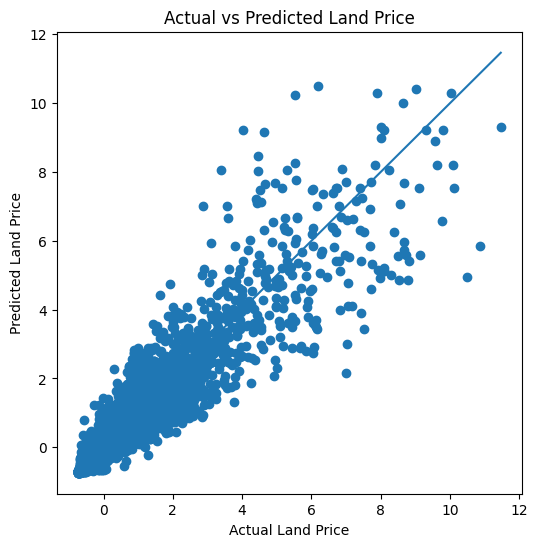

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Land Price")
plt.ylabel("Predicted Land Price")

plt.title("Actual vs Predicted Land Price")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

## 9. Future Prediction Function

In [27]:
def PredictLandPrice():

    import pandas as pd
    import numpy as np
    import joblib

    print("🏡 Future Land Price Prediction – Input Based Prediction")
    print("========================================================")

#     # ---- Load saved objects ----
#     encoder = joblib.load("encoder.pkl")
#     scaler_X = joblib.load("scaler_X.pkl")
#     scaler_y = joblib.load("scaler_y.pkl")
#     model = joblib.load("model.pkl")

    data = pd.read_csv("final_land_price_65k.csv")

    # ---- USER INPUTS ----
    print("Available Cities:", data['city'].unique())
    city = input("Enter City: ")

    print("Available States:", data['state'].unique())
    state = input("Enter State: ")

    print("Available Zoning:", data['zoning'].unique())
    zoning = input("Enter Zoning: ")

    print("Available Locality:", data['locality'].unique())
    locality = input("Enter Locality: ")

    city_tier = int(input(f"City Tier ({data.city_tier.min()}–{data.city_tier.max()}): "))

    
    land_area_sqft = float(input(f"Land Area Sqft ({data.land_area_sqft.min()}–{data.land_area_sqft.max()}): "))

    
    dist_city = float(input(f"Distance from City Center KM ({data.dist_city_center_km.min()}–{data.dist_city_center_km.max()}): "))

    dist_highway = float(input(f"Distance from Highway KM ({data.dist_highway_km.min()}–{data.dist_highway_km.max()}): "))

    dist_transport = float(input(f"Distance from Transport KM ({data.dist_transport_km.min()}–{data.dist_transport_km.max()}): "))

    dist_amenities = float(input(f"Distance to Amenities KM ({data.dist_amenities_km.min()}–{data.dist_amenities_km.max()}): "))

    hist_growth = float(input(f"Historical Growth % ({data.historical_growth_pct.min()}–{data.historical_growth_pct.max()}): "))

    pop_growth = float(input(f"Population Growth % ({data.population_growth_pct.min()}–{data.population_growth_pct.max()}): "))

    road_quality = float(input(f"Road Quality Score ({data.road_quality_score.min()}–{data.road_quality_score.max()}): "))
    
   
    utility_access = int(input(f"utility_access ({data.utility_access.min()}–{data.utility_access.max()}): "))
    
    
    govt_dev_plan =  int(input(f"govt_dev_plan ({data.govt_dev_plan.min()}–{data.govt_dev_plan.max()}): "))
    

    flood_risk = int(input(f"flood_risk ({data.flood_risk.min()}–{data.flood_risk.max()}): "))
    


    # ---- Create full feature row (ALL features used in training) ----
    row = pd.DataFrame([[

       
        state,
        city,
        locality,
        city_tier,
        zoning,
        land_area_sqft,
        dist_city,
        dist_highway,
        dist_transport,
        dist_amenities,
        hist_growth,
        pop_growth,
        road_quality,
        utility_access,
        govt_dev_plan,
        flood_risk,
       

    ]], columns=[

        
        "state",
        "city",
        "locality",
        "city_tier",
        "zoning",
        "land_area_sqft",
        "dist_city_center_km",
        "dist_highway_km",
        "dist_transport_km",
        "dist_amenities_km",
        "historical_growth_pct",
        "population_growth_pct",
        "road_quality_score",
        "utility_access",
        "govt_dev_plan",
        "flood_risk",
        

    ])

    print("\nGiven User Input Data:")
    display(row)
    current_price = float(input("Enter Current Price per Sqft: "))


    # ---- Encode categorical ----
    categorical_cols = ["state","city","locality","zoning"]
    row[categorical_cols] = encoder.transform(row[categorical_cols])

    # ---- Scale X using SAME scaler ----
    row_scaled = scaler_X.transform(row)

    # ---- Predict (scaled y) ----
    y_pred_scaled = model.predict(row_scaled)

    # ---- Inverse scale to get real price ----
    y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))[0][0]

    # ---- Results ----
    print("\n********** Prediction ***********\n")
    print(f"Predicted Future Land Price per Sqft (2026): ₹ {round(y_pred_original,2)}")

    profit = y_pred_original - current_price
    roi = (profit / current_price) * 100

    print("\n===== INVESTMENT ANALYSIS =====")
    print("Current Price per sqft:", current_price)
    print("Future Price per sqft:", round(y_pred_original,2))
    print("Expected Profit per sqft:", round(profit,2))
    print("ROI %:", round(roi,2))

    return y_pred_original

## User Input 1

In [28]:
 PredictLandPrice()

🏡 Future Land Price Prediction – Input Based Prediction
Available Cities: ['Kanpur' 'Mumbai' 'Chandigarh' 'Surat' 'Delhi' 'Coimbatore' 'Mangaluru'
 'Nellore' 'Gwalior' 'Thiruvananthapuram' 'Ahmedabad' 'Hubballi'
 'Hyderabad' 'Kochi' 'Madurai' 'Belagavi' 'Kolkata' 'Chennai' 'Pune'
 'Tirupati' 'Vadodara' 'Jaipur' 'Jodhpur' 'Mysuru' 'Warangal' 'Nagpur'
 'Agra' 'Kozhikode' 'Tiruchirappalli' 'Lucknow' 'Nashik' 'Bengaluru'
 'Visakhapatnam' 'Vijayawada' 'Varanasi' 'Salem' 'Rajkot' 'Indore']
Enter City: Jaipur
Available States: ['Uttar Pradesh' 'Maharashtra' 'Chandigarh' 'Gujarat' 'Delhi' 'Tamil Nadu'
 'Karnataka' 'Andhra Pradesh' 'Madhya Pradesh' 'Kerala' 'Telangana'
 'West Bengal' 'Rajasthan']
Enter State: Rajasthan
Available Zoning: ['Commercial' 'Agricultural' 'Industrial' 'Residential']
Enter Zoning: Agricultural
Available Locality: ['The Mall Road' 'Murbad' 'Sector 17 Plaza' 'Vyara' 'Narela Industrial'
 'Palladam' 'MSEZ' 'Old Town Nellore' 'Bajpe' 'Dabra' 'Peroorkada'
 'CG Road' 'Tarihal

,state,city,locality,city_tier,zoning,land_area_sqft,dist_city_center_km,dist_highway_km,dist_transport_km,dist_amenities_km,historical_growth_pct,population_growth_pct,road_quality_score,utility_access,govt_dev_plan,flood_risk
0,Rajasthan,Jaipur,Chomu,2,Agricultural,25485.62,40.82,21.49,15.16,2.66,9.38,3.95,8.63,0,0,1


Enter Current Price per Sqft: 781.41

********** Prediction ***********

Predicted Future Land Price per Sqft (2026): ₹ 1244.23

===== INVESTMENT ANALYSIS =====
Current Price per sqft: 781.41
Future Price per sqft: 1244.23
Expected Profit per sqft: 462.82
ROI %: 59.23


1244.2299999999996

In [ ]:
Jaipur	Rajasthan	2	2021	1	Chomu	40.82	21.49	15.16	2.66	6.72	309.26	9.38	3.95	8.63	25485.62	0	0	1	19914718.32	0.0975	1244.23	31709972.97	Agricultural	781.41
city	state	city_tier	year	quarter	locality	dist_city_center_km	dist_highway_km	dist_transport_km	dist_amenities_km	soil_quality_score	elevation_m	historical_growth_pct	population_growth_pct	road_quality_score	land_area_sqft	utility_access	govt_dev_plan	flood_risk	total_land_price_inr	combined_growth_rate	predicted_price_sqft_2026	predicted_total_land_price_2026	zoning	land_price_per_sqft_inr


## Generating Pickle File

In [33]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------
# 1. Load Dataset
# -------------------------------------------------
df = pd.read_csv("final_land_price_65k.csv")

# -------------------------------------------------
# 2. Select ONLY the features you use in Streamlit
# -------------------------------------------------
features = [
    "state", "city", "locality", "city_tier", "zoning",
    "land_area_sqft",
    "dist_city_center_km", "dist_highway_km", "dist_transport_km", "dist_amenities_km",
    "historical_growth_pct", "population_growth_pct",
    "road_quality_score",
    "utility_access", "govt_dev_plan", "flood_risk"
]

target_col = "predicted_price_sqft_2026"

X = df[features].copy()
y = df[target_col].copy()

# -------------------------------------------------
# 3. Identify categorical columns
# -------------------------------------------------
categorical_cols = ["state", "city", "locality", "zoning"]

# -------------------------------------------------
# 4. Encode categorical features
# -------------------------------------------------
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

# -------------------------------------------------
# 5. Scale X and y
# -------------------------------------------------
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# -------------------------------------------------
# 6. Train Model
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train.ravel())

# -------------------------------------------------
# 7. Evaluate
# -------------------------------------------------
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

# -------------------------------------------------
# 8. Save EVERYTHING together
# -------------------------------------------------
pipeline = {
    "encoder": encoder,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "model": model,
    "columns": X.columns.tolist(),   # This will be EXACT 16 columns
    "categorical_cols": categorical_cols
}

with open("land_price_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ land_price_pipeline.pkl created successfully")

RMSE: 0.27797469265317076
R2 Score: 0.9332974047341136
✅ land_price_pipeline.pkl created successfully
